In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


print("GROCERY ASSORTMENT RATIONALIZATION ANALYSIS")
df = pd.read_csv('/content/Grocery_Dataset_python_mock_project.csv')

# Basic information about the dataset
print(f"Dataset Shape: {df.shape[0]} products, {df.shape[1]} features")
print(f"\nColumn Names:")
print(df.columns.tolist())

GROCERY ASSORTMENT RATIONALIZATION ANALYSIS
Dataset Shape: 5000 products, 15 features

Column Names:
['Product_ID', 'Category', 'Product_Name', 'Brand', 'Price', 'Cost', 'Units_Sold', 'SKU', 'Shelf_Space', 'Customer_Ratings', 'Frequency_of_Purchase', 'Sales', 'Gross_Margin', 'Total_Customers', 'Total_Transactions']


In [ ]:
# Data types and missing values
print("\nData Info:")
print(df.info())

print("\nMissing Values:")
print(df.isna().sum())

# Basic statistics
print("\nBasic Statistics:")
print(df.describe())


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Product_ID             5000 non-null   object 
 1   Category               5000 non-null   object 
 2   Product_Name           5000 non-null   object 
 3   Brand                  5000 non-null   object 
 4   Price                  5000 non-null   float64
 5   Cost                   5000 non-null   float64
 6   Units_Sold             5000 non-null   int64  
 7   SKU                    5000 non-null   int64  
 8   Shelf_Space            5000 non-null   float64
 9   Customer_Ratings       5000 non-null   float64
 10  Frequency_of_Purchase  5000 non-null   int64  
 11  Sales                  5000 non-null   float64
 12  Gross_Margin           5000 non-null   float64
 13  Total_Customers        5000 non-null   int64  
 14  Total_Transactions     5000 non-null   int64

In [ ]:
# DESCRIPTIVE ANALYTICS
# Sales and Gross Margin Distribution by Category

category_analysis = df.groupby('Category').agg({
    'Sales': ['sum', 'mean', 'std'],
    'Gross_Margin': ['sum', 'mean', 'std'],
    'Product_ID': 'count'
}).round(2)

category_analysis.columns = ['Total_Sales', 'Avg_Sales', 'Std_Sales',
                             'Total_Margin', 'Avg_Margin', 'Std_Margin', 'Product_Count']
category_analysis = category_analysis.sort_values('Total_Sales', ascending=False)

print("\nCategory Performance Summary:")
print(category_analysis)


Category Performance Summary:
           Total_Sales  Avg_Sales  Std_Sales  Total_Margin  Avg_Margin  \
Category                                                                 
Bakery     91628898.59   89306.92   61500.25   24262608.30    23647.77   
Frozen     75781533.72   95683.75   63485.45   21977677.20    27749.59   
Dairy      74632425.65   89060.17   62761.73   17135787.54    20448.43   
Produce    71722990.52   91600.24   64532.17   19489257.74    24890.50   
Beverages  70885761.33   89389.36   61554.20   15364810.87    19375.55   
Snacks     70022619.96   91175.29   61717.59   16515024.27    21503.94   

           Std_Margin  Product_Count  
Category                              
Bakery       67029.18           1026  
Frozen       66997.78            792  
Dairy        68013.07            838  
Produce      71986.66            783  
Beverages    68064.31            793  
Snacks       68112.50            768  


In [ ]:
# Calculate category contribution percentages
total_sales = df['Sales'].sum()
total_margin = df['Gross_Margin'].sum()

category_analysis['Sales_Contribution_%'] = (category_analysis['Total_Sales'] / total_sales * 100).round(2)
category_analysis['Margin_Contribution_%'] = (category_analysis['Total_Margin'] / total_margin * 100).round(2)

print("\nCategory Contribution to Business:")
print(category_analysis[['Sales_Contribution_%', 'Margin_Contribution_%']])


Category Contribution to Business:
           Sales_Contribution_%  Margin_Contribution_%
Category                                              
Bakery                    20.15                  21.14
Frozen                    16.67                  19.15
Dairy                     16.41                  14.93
Produce                   15.77                  16.98
Beverages                 15.59                  13.39
Snacks                    15.40                  14.39


In [ ]:
# Brand Analysis

brand_analysis = df.groupby('Brand').agg({
    'Sales': ['sum', 'mean'],
    'Gross_Margin': ['sum', 'mean'],
    'Product_ID': 'count'
}).round(2)

brand_analysis.columns = ['Total_Sales', 'Avg_Sales', 'Total_Margin', 'Avg_Margin', 'Product_Count']
brand_analysis = brand_analysis.sort_values('Total_Sales', ascending=False)

print("\nBrand Performance Summary:")
print(brand_analysis)


Brand Performance Summary:
          Total_Sales  Avg_Sales  Total_Margin  Avg_Margin  Product_Count
Brand                                                                    
Brand A  1.193804e+08   93485.03   34051849.56    26665.50           1277
Brand D  1.032132e+08   90458.58   23648357.07    20725.99           1141
Brand C  9.322142e+07   90682.31   23061265.56    22433.14           1028
Brand B  7.695172e+07   91827.82   21156607.11    25246.55            838
Brand E  6.190748e+07   86462.96   12827086.62    17914.93            716


In [ ]:
# Top and Bottom Performers

# Top 10 products by sales
top_sales = df.nlargest(10, 'Sales')[['Product_ID', 'Product_Name', 'Category', 'Brand', 'Sales', 'Gross_Margin']]
print("\nTop 10 Products by Sales:")
print(top_sales.to_string(index=False))

# Top 10 products by gross margin
top_margin = df.nlargest(10, 'Gross_Margin')[['Product_ID', 'Product_Name', 'Category', 'Brand', 'Sales', 'Gross_Margin']]
print("\nTop 10 Products by Gross Margin:")
print(top_margin.to_string(index=False))

# Bottom 10 products by sales
bottom_sales = df.nsmallest(10, 'Sales')[['Product_ID', 'Product_Name', 'Category', 'Brand', 'Sales', 'Gross_Margin']]
print("\nBottom 10 Products by Sales:")
print(bottom_sales.to_string(index=False))

# Products with negative margins
negative_margin = df[df['Gross_Margin'] < 0].sort_values('Gross_Margin')
print(f"\nProducts with Negative Margins: {len(negative_margin)} products")
if len(negative_margin) > 0:
    print(negative_margin[['Product_ID', 'Product_Name', 'Category', 'Brand', 'Gross_Margin', 'Sales']].head(10).to_string(index=False))



Top 10 Products by Sales:
Product_ID Product_Name  Category   Brand     Sales  Gross_Margin
    P00312  Product 312     Dairy Brand B 263920.92     142610.28
    P02408 Product 2408   Produce Brand C 263808.50     103148.00
    P03950 Product 3950    Snacks Brand B 262735.80     214813.05
    P02154 Product 2154   Produce Brand B 260268.06     154452.27
    P00919  Product 919 Beverages Brand C 259572.00      64331.04
    P01078 Product 1078     Dairy Brand C 259028.64     208977.08
    P04673 Product 4673 Beverages Brand A 257574.32     228028.72
    P04101 Product 4101    Bakery Brand A 257205.78     238368.78
    P04911 Product 4911    Frozen Brand E 256718.70     210368.88
    P04332 Product 4332    Snacks Brand E 254231.25     102109.70

Top 10 Products by Gross Margin:
Product_ID Product_Name  Category   Brand     Sales  Gross_Margin
    P03237 Product 3237     Dairy Brand C 250534.70     245136.55
    P04966 Product 4966    Frozen Brand C 254091.50     238846.01
    P04101 Prod

In [ ]:
# exploratory data analysis

In [ ]:
# CUSTOMER DEMAND ANALYSIS

# Customer Ratings Analysis
ratings_stats = df['Customer_Ratings'].describe()
print("\nCustomer Ratings Statistics:")
print(ratings_stats)

# Ratings by category
ratings_by_category = df.groupby('Category')['Customer_Ratings'].agg(['mean', 'std', 'min', 'max']).round(2)
print("\nAverage Ratings by Category:")
print(ratings_by_category.sort_values('mean', ascending=False))


Customer Ratings Statistics:
count    5000.000000
mean        3.764120
std         0.690495
min         2.500000
25%         3.200000
50%         3.800000
75%         4.300000
max         5.000000
Name: Customer_Ratings, dtype: float64

Average Ratings by Category:
           mean   std  min  max
Category                       
Snacks     3.80  0.69  2.5  5.0
Produce    3.79  0.69  2.5  5.0
Bakery     3.76  0.69  2.5  5.0
Beverages  3.75  0.68  2.5  5.0
Frozen     3.75  0.68  2.5  5.0
Dairy      3.74  0.71  2.5  5.0


In [ ]:
# Frequency of Purchase Analysis
freq_stats = df['Frequency_of_Purchase'].describe()
print("\nFrequency of Purchase Statistics:")
print(freq_stats)

# High frequency products
high_freq = df[df['Frequency_of_Purchase'] >= df['Frequency_of_Purchase'].quantile(0.75)]
print(f"\nHigh Frequency Products (Top 25%): {len(high_freq)} products")
print(f"Average Sales of High Frequency Products: €{high_freq['Sales'].mean():,.2f}")
print(f"Average Margin of High Frequency Products: €{high_freq['Gross_Margin'].mean():,.2f}")


Frequency of Purchase Statistics:
count    5000.000000
mean       54.092200
std        26.050985
min        10.000000
25%        32.000000
50%        54.000000
75%        76.000000
max        99.000000
Name: Frequency_of_Purchase, dtype: float64

High Frequency Products (Top 25%): 1313 products
Average Sales of High Frequency Products: €92,605.36
Average Margin of High Frequency Products: €23,779.93


In [ ]:
#  Correlation Analysis

demand_corr = df[['Customer_Ratings', 'Frequency_of_Purchase', 'Sales', 'Units_Sold', 'Gross_Margin']].corr()
print("\nCorrelation Matrix (Demand Metrics):")
print(demand_corr.round(3))

# Products with high ratings but low sales (potential opportunities)
high_rating_low_sales = df[(df['Customer_Ratings'] >= 4.0) & (df['Sales'] < df['Sales'].median())]
print(f"\nProducts with High Ratings (≥4.0) but Below Median Sales: {len(high_rating_low_sales)} products")
if len(high_rating_low_sales) > 0:
    print("Sample of Opportunity Products:")
    print(high_rating_low_sales[['Product_ID', 'Product_Name', 'Category', 'Customer_Ratings', 'Sales']].head(5).to_string(index=False))



Correlation Matrix (Demand Metrics):
                       Customer_Ratings  Frequency_of_Purchase  Sales  \
Customer_Ratings                  1.000                 -0.010 -0.005   
Frequency_of_Purchase            -0.010                  1.000  0.012   
Sales                            -0.005                  0.012  1.000   
Units_Sold                        0.015                  0.017  0.487   
Gross_Margin                     -0.023                  0.003  0.739   

                       Units_Sold  Gross_Margin  
Customer_Ratings            0.015        -0.023  
Frequency_of_Purchase       0.017         0.003  
Sales                       0.487         0.739  
Units_Sold                  1.000         0.116  
Gross_Margin                0.116         1.000  

Products with High Ratings (≥4.0) but Below Median Sales: 1107 products
Sample of Opportunity Products:
Product_ID Product_Name Category  Customer_Ratings    Sales
    P00003    Product 3   Snacks               4.4  3592.6

In [ ]:
# INVENTORY OPTIMIZATION

# Stock Turnover Analysis

# Calculate stock turnover rate (Units Sold / SKU)
df['Stock_Turnover'] = df['Units_Sold'] / df['SKU']
df['Stock_Turnover'] = df['Stock_Turnover'].replace([np.inf, -np.inf], np.nan)

turnover_stats = df['Stock_Turnover'].describe()
print("\nStock Turnover Statistics:")
print(turnover_stats)

# Identify slow-moving items (bottom 25% turnover)
slow_moving = df[df['Stock_Turnover'] <= df['Stock_Turnover'].quantile(0.25)]
print(f"\nSlow-Moving Items (Bottom 25% Turnover): {len(slow_moving)} products")
print(f"Total Sales of Slow-Moving Items: €{slow_moving['Sales'].sum():,.2f}")
print(f"Total Margin of Slow-Moving Items: €{slow_moving['Gross_Margin'].sum():,.2f}")

# Fast-moving items (top 25% turnover)
fast_moving = df[df['Stock_Turnover'] >= df['Stock_Turnover'].quantile(0.75)]
print(f"\nFast-Moving Items (Top 25% Turnover): {len(fast_moving)} products")
print(f"Total Sales of Fast-Moving Items: €{fast_moving['Sales'].sum():,.2f}")
print(f"Total Margin of Fast-Moving Items: €{fast_moving['Gross_Margin'].sum():,.2f}")


Stock Turnover Statistics:
count    5000.000000
mean       90.641083
std        76.043684
min         3.255319
25%        43.854076
50%        64.244403
75%       109.988652
max       529.300000
Name: Stock_Turnover, dtype: float64

Slow-Moving Items (Bottom 25% Turnover): 1250 products
Total Sales of Slow-Moving Items: €74,454,148.21
Total Margin of Slow-Moving Items: €17,340,048.73

Fast-Moving Items (Top 25% Turnover): 1250 products
Total Sales of Fast-Moving Items: €133,262,152.74
Total Margin of Fast-Moving Items: €36,637,895.11


In [ ]:
# Shelf Space Utilization

# Calculate sales per shelf space
df['Sales_per_Shelf'] = df['Sales'] / df['Shelf_Space']
df['Sales_per_Shelf'] = df['Sales_per_Shelf'].replace([np.inf, -np.inf], np.nan)

# Calculate margin per shelf space
df['Margin_per_Shelf'] = df['Gross_Margin'] / df['Shelf_Space']
df['Margin_per_Shelf'] = df['Margin_per_Shelf'].replace([np.inf, -np.inf], np.nan)

shelf_stats = df[['Sales_per_Shelf', 'Margin_per_Shelf']].describe()
print("\nShelf Space Efficiency Statistics:")
print(shelf_stats)

# Over-utilized products (high sales per shelf)
efficient_shelf = df[df['Sales_per_Shelf'] >= df['Sales_per_Shelf'].quantile(0.75)]
print(f"\nHighly Efficient Shelf Users (Top 25%): {len(efficient_shelf)} products")
print("These products might need MORE shelf space")

# Under-utilized products (low sales per shelf)
inefficient_shelf = df[df['Sales_per_Shelf'] <= df['Sales_per_Shelf'].quantile(0.25)]
print(f"\nInefficient Shelf Users (Bottom 25%): {len(inefficient_shelf)} products")
print("These products might need LESS shelf space or removal")


Shelf Space Efficiency Statistics:
       Sales_per_Shelf  Margin_per_Shelf
count      5000.000000       5000.000000
mean      51002.057644      13194.685434
std       61450.799373      50313.920012
min         328.957627    -285962.793103
25%       14569.551003      -7383.913112
50%       30774.845889       7896.100169
75%       59507.510313      26921.541869
max      485588.160000     420887.120000

Highly Efficient Shelf Users (Top 25%): 1250 products
These products might need MORE shelf space

Inefficient Shelf Users (Bottom 25%): 1250 products
These products might need LESS shelf space or removal


In [ ]:
#. PROFITABILITY ANALYSIS

#  Margin Analysis

# Calculate margin percentage
df['Margin_Percentage'] = (df['Gross_Margin'] / df['Sales'] * 100).replace([np.inf, -np.inf], np.nan)

margin_stats = df['Margin_Percentage'].describe()
print("\nMargin Percentage Statistics:")
print(margin_stats)

# High margin products
high_margin = df[df['Margin_Percentage'] >= 40]  # 40% or higher margin
print(f"\nHigh Margin Products (≥40%): {len(high_margin)} products")
print(f"Average Sales of High Margin Products: €{high_margin['Sales'].mean():,.2f}")


Margin Percentage Statistics:
count    5000.000000
mean      -63.416661
std       274.785016
min     -2430.128205
25%       -47.081030
50%        25.159373
75%        62.406254
max        97.845348
Name: Margin_Percentage, dtype: float64

High Margin Products (≥40%): 2058 products
Average Sales of High Margin Products: €119,997.21


In [ ]:

# Product Segmentation

# Define thresholds
sales_median = df['Sales'].median()
margin_median = df['Gross_Margin'].median()

# Segment products
df['Segment'] = 'Low Sales - Low Margin'
df.loc[(df['Sales'] >= sales_median) & (df['Gross_Margin'] >= margin_median), 'Segment'] = 'Stars (High Sales - High Margin)'
df.loc[(df['Sales'] >= sales_median) & (df['Gross_Margin'] < margin_median), 'Segment'] = 'High Sales - Low Margin'
df.loc[(df['Sales'] < sales_median) & (df['Gross_Margin'] >= margin_median), 'Segment'] = 'Low Sales - High Margin'

segment_summary = df.groupby('Segment').agg({
    'Product_ID': 'count',
    'Sales': 'sum',
    'Gross_Margin': 'sum'
}).round(2)

segment_summary.columns = ['Product_Count', 'Total_Sales', 'Total_Margin']
print("\nProduct Segmentation Summary:")
print(segment_summary)


Product Segmentation Summary:
                                  Product_Count   Total_Sales  Total_Margin
Segment                                                                    
High Sales - Low Margin                     537  6.342411e+07 -7.706890e+06
Low Sales - High Margin                     537  3.241945e+07  2.150569e+07
Low Sales - Low Margin                     1963  6.448540e+07 -6.903288e+07
Stars (High Sales - High Margin)           1963  2.943453e+08  1.699792e+08


In [ ]:
# RECOMMENDATIONS AND ACTIONABLE INSIGHTS

# Products to ELIMINATE

# Criteria for elimination
  eliminate = df[
      (df['Gross_Margin'] < 0) |  # Negative margin
      ((df['Sales'] < df['Sales'].quantile(0.1)) & (df['Customer_Ratings'] < 3.0)) |  # Low sales and low ratings
      ((df['Stock_Turnover'] < df['Stock_Turnover'].quantile(0.1)) & (df['Margin_per_Shelf'] < 0))  # Very slow moving with negative shelf margin
  ]

  print(f"Recommended for Elimination: {len(eliminate)} products")
  print("\nElimination List (Top 20):")
  eliminate_list = eliminate[['Product_ID', 'Product_Name', 'Category', 'Brand', 'Sales', 'Gross_Margin', 'Customer_Ratings']].head(20)
  print(eliminate_list.to_string(index=False))

  print(f"\nPotential Savings from Elimination:")
  print(f"- Negative Margin Recovery: €{abs(eliminate[eliminate['Gross_Margin'] < 0]['Gross_Margin'].sum()):,.2f}")
  print(f"- Shelf Space to Reallocate: {eliminate['Shelf_Space'].sum():.2f} sq. meters")

Recommended for Elimination: 1873 products

Elimination List (Top 20):
Product_ID Product_Name  Category   Brand     Sales  Gross_Margin  Customer_Ratings
    P00003    Product 3    Snacks Brand A   3592.68     -66257.31               4.4
    P00007    Product 7   Produce Brand E  86986.40     -58656.80               3.3
    P00010   Product 10    Snacks Brand B  77936.67       -203.49               3.5
    P00011   Product 11    Bakery Brand C 152705.74     -17483.22               3.1
    P00015   Product 15 Beverages Brand A 129233.10     -26779.23               4.8
    P00019   Product 19     Dairy Brand A  75082.98     -29513.75               4.1
    P00021   Product 21 Beverages Brand A  82473.30     -36268.96               4.3
    P00022   Product 22 Beverages Brand A  56894.20     -26989.48               2.6
    P00024   Product 24 Beverages Brand D  66735.48     -35376.40               3.5
    P00027   Product 27   Produce Brand C  24907.85    -131579.32               4.0
    P

In [ ]:
# Products to INCREASE FOCUS

# Criteria for increased focus
increase_focus = df[
    ((df['Sales'] >= df['Sales'].quantile(0.75)) & (df['Gross_Margin'] >= df['Gross_Margin'].quantile(0.75))) |  # High performers
    ((df['Customer_Ratings'] >= 4.5) & (df['Frequency_of_Purchase'] >= df['Frequency_of_Purchase'].quantile(0.75))) |  # Customer favorites
    (df['Sales_per_Shelf'] >= df['Sales_per_Shelf'].quantile(0.9))  # Highly efficient shelf use
]

print(f"Recommended for Increased Focus: {len(increase_focus)} products")
print("\nTop Products to Prioritize (Top 20):")
focus_list = increase_focus.nlargest(20, 'Gross_Margin')[['Product_ID', 'Product_Name', 'Category', 'Brand', 'Sales', 'Gross_Margin', 'Customer_Ratings']]
print(focus_list.to_string(index=False))

Recommended for Increased Focus: 1318 products

Top Products to Prioritize (Top 20):
Product_ID Product_Name  Category   Brand     Sales  Gross_Margin  Customer_Ratings
    P03237 Product 3237     Dairy Brand C 250534.70     245136.55               4.8
    P04966 Product 4966    Frozen Brand C 254091.50     238846.01               3.1
    P04101 Product 4101    Bakery Brand A 257205.78     238368.78               3.8
    P01171 Product 1171    Bakery Brand A 241263.75     235968.32               2.6
    P00670  Product 670    Frozen Brand A 239656.05     231825.15               3.1
    P04673 Product 4673 Beverages Brand A 257574.32     228028.72               3.3
    P04917 Product 4917    Bakery Brand D 238911.00     225463.02               3.6
    P03746 Product 3746    Frozen Brand C 225624.36     220533.30               2.8
    P01608 Product 1608   Produce Brand D 253159.56     220103.04               4.4
    P00334  Product 334    Frozen Brand E 243609.60     217804.80          

In [ ]:
# Products with OPPORTUNITY

# High potential products (high ratings but underperforming in sales)
opportunities = df[
    (df['Customer_Ratings'] >= 4.0) &
    (df['Sales'] < df['Sales'].median()) &
    (df['Margin_Percentage'] > 20)
]

print(f"Products with Growth Potential: {len(opportunities)} products")
print("\nOpportunity List (Top 15):")
opp_list = opportunities.nlargest(15, 'Customer_Ratings')[['Product_ID', 'Product_Name', 'Category', 'Customer_Ratings', 'Sales', 'Gross_Margin']]
print(opp_list.to_string(index=False))

Products with Growth Potential: 348 products

Opportunity List (Top 15):
Product_ID Product_Name  Category  Customer_Ratings    Sales  Gross_Margin
    P00541  Product 541 Beverages               5.0 63291.42      30799.80
    P01295 Product 1295   Produce               5.0 50320.00      25925.00
    P02709 Product 2709     Dairy               5.0 78259.50      61632.65
    P04292 Product 4292 Beverages               5.0 81372.20      46905.04
    P00009    Product 9     Dairy               4.9 32393.12      24464.68
    P00187  Product 187     Dairy               4.9 21978.84      18412.20
    P00222  Product 222     Dairy               4.9 52581.27      16989.28
    P00306  Product 306    Snacks               4.9 79690.38      56870.94
    P00348  Product 348    Snacks               4.9 24034.98      13221.60
    P00377  Product 377    Snacks               4.9 55973.60      34605.30
    P00535  Product 535    Snacks               4.9 60765.43      33685.63
    P00662  Product 662    

In [ ]:
# CATEGORY-SPECIFIC RECOMMENDATIONS

for category in df['Category'].unique():
    cat_df = df[df['Category'] == category]

    print(f"\n{category.upper()} Category:")
    print("-" * 30)

    # Category statistics
    print(f"Total Products: {len(cat_df)}")
    print(f"Total Sales: €{cat_df['Sales'].sum():,.2f}")
    print(f"Total Margin: €{cat_df['Gross_Margin'].sum():,.2f}")
    print(f"Average Rating: {cat_df['Customer_Ratings'].mean():.2f}")

    # Recommendations
    cat_eliminate = len(cat_df[cat_df['Product_ID'].isin(eliminate['Product_ID'])])
    cat_focus = len(cat_df[cat_df['Product_ID'].isin(increase_focus['Product_ID'])])

    print(f"\nRecommendations:")
    print(f"- Products to Eliminate: {cat_eliminate}")
    print(f"- Products to Focus On: {cat_focus}")

    # Top performer in category
    top_product = cat_df.nlargest(1, 'Gross_Margin').iloc[0]
    print(f"- Star Product: {top_product['Product_Name']} (Margin: €{top_product['Gross_Margin']:,.2f})")

    # Worst performer in category
    if len(cat_df[cat_df['Gross_Margin'] < 0]) > 0:
        worst_product = cat_df.nsmallest(1, 'Gross_Margin').iloc[0]
        print(f"- Worst Product: {worst_product['Product_Name']} (Margin: €{worst_product['Gross_Margin']:,.2f})")


SNACKS Category:
------------------------------
Total Products: 768
Total Sales: €70,022,619.96
Total Margin: €16,515,024.27
Average Rating: 3.80

Recommendations:
- Products to Eliminate: 292
- Products to Focus On: 198
- Star Product: Product 3950 (Margin: €214,813.05)
- Worst Product: Product 3606 (Margin: €-178,830.72)

FROZEN Category:
------------------------------
Total Products: 792
Total Sales: €75,781,533.72
Total Margin: €21,977,677.20
Average Rating: 3.75

Recommendations:
- Products to Eliminate: 270
- Products to Focus On: 226
- Star Product: Product 4966 (Margin: €238,846.01)
- Worst Product: Product 4998 (Margin: €-185,357.60)

DAIRY Category:
------------------------------
Total Products: 838
Total Sales: €74,632,425.65
Total Margin: €17,135,787.54
Average Rating: 3.74

Recommendations:
- Products to Eliminate: 327
- Products to Focus On: 209
- Star Product: Product 3237 (Margin: €245,136.55)
- Worst Product: Product 1354 (Margin: €-160,475.43)

BAKERY Category:
-----

In [ ]:
# EXECUTIVE SUMMARY

print(f"Total Products: {len(df)}")
print(f"Total Annual Sales: €{df['Sales'].sum():,.2f}")
print(f"Total Gross Margin: €{df['Gross_Margin'].sum():,.2f}")
print(f"Average Margin %: {df['Margin_Percentage'].mean():.1f}%")
print(f"Products with Negative Margin: {len(df[df['Gross_Margin'] < 0])}")

print("\n🎯 KEY FINDINGS")
print("-" * 40)
print(f"1. {len(eliminate)} products ({len(eliminate)/len(df)*100:.1f}%) should be eliminated")
print(f"2. {len(increase_focus)} products ({len(increase_focus)/len(df)*100:.1f}%) deserve increased focus")
print(f"3. {len(opportunities)} products ({len(opportunities)/len(df)*100:.1f}%) have untapped growth potential")
print(f"4. Potential margin recovery from eliminations: €{abs(eliminate[eliminate['Gross_Margin'] < 0]['Gross_Margin'].sum()):,.2f}")

print("\n💡 STRATEGIC RECOMMENDATIONS")
print("-" * 40)
print("1. IMMEDIATE ACTIONS:")
print("   - Eliminate all negative margin products immediately")
print("   - Reallocate shelf space from slow-moving to fast-moving items")
print("   - Increase inventory for top-rated, high-frequency products")

print("\n2. SHORT-TERM (3 months):")
print("   - Negotiate better terms with suppliers for high-volume, low-margin products")
print("   - Launch promotions for high-rated but low-sales products")
print("   - Optimize category mix based on profitability analysis")

print("\n3. LONG-TERM (6-12 months):")
print("   - Develop private label alternatives for high-margin categories")
print("   - Implement dynamic pricing for seasonal and perishable items")
print("   - Create customer loyalty programs focusing on high-margin products")

print("\n📈 EXPECTED IMPACT")
print("-" * 40)
if len(eliminate) > 0:
    expected_margin_improvement = abs(eliminate[eliminate['Gross_Margin'] < 0]['Gross_Margin'].sum())
    expected_sales_impact = eliminate['Sales'].sum()
    remaining_sales = df['Sales'].sum() - expected_sales_impact
    remaining_margin = df['Gross_Margin'].sum() + expected_margin_improvement
    new_margin_pct = (remaining_margin / remaining_sales * 100) if remaining_sales > 0 else 0

    print(f"After implementing recommendations:")
    print(f"- Margin improvement: €{expected_margin_improvement:,.2f}")
    print(f"- New margin %: {new_margin_pct:.1f}% (from {df['Margin_Percentage'].mean():.1f}%)")
    print(f"- Freed shelf space: {eliminate['Shelf_Space'].sum():.1f} sq. meters")
    print(f"- Reduced SKU complexity: {len(eliminate)} fewer products to manage")



# Save elimination list
eliminate_export = eliminate[['Product_ID', 'Product_Name', 'Category', 'Brand', 'Sales', 'Gross_Margin', 'Customer_Ratings', 'Stock_Turnover']]
eliminate_export.to_csv('products_to_eliminate.csv', index=False)
print("✓ Saved: products_to_eliminate.csv")

# Save focus list
focus_export = increase_focus[['Product_ID', 'Product_Name', 'Category', 'Brand', 'Sales', 'Gross_Margin', 'Customer_Ratings', 'Stock_Turnover']]
focus_export.to_csv('products_to_focus.csv', index=False)
print("✓ Saved: products_to_focus.csv")

# Save opportunities list
opp_export = opportunities[['Product_ID', 'Product_Name', 'Category', 'Brand', 'Sales', 'Gross_Margin', 'Customer_Ratings', 'Margin_Percentage']]
opp_export.to_csv('growth_opportunities.csv', index=False)
print("✓ Saved: growth_opportunities.csv")

# Save complete analysis with segments
analysis_export = df[['Product_ID', 'Product_Name', 'Category', 'Brand', 'Sales', 'Gross_Margin',
                      'Customer_Ratings', 'Stock_Turnover', 'Sales_per_Shelf', 'Margin_Percentage', 'Segment']]
analysis_export.to_csv('complete_analysis.csv', index=False)


Total Products: 5000
Total Annual Sales: €454,674,229.77
Total Gross Margin: €114,745,165.92
Average Margin %: -63.4%
Products with Negative Margin: 1866

🎯 KEY FINDINGS
----------------------------------------
1. 1873 products (37.5%) should be eliminated
2. 1318 products (26.4%) deserve increased focus
3. 348 products (7.0%) have untapped growth potential
4. Potential margin recovery from eliminations: €83,092,387.41

💡 STRATEGIC RECOMMENDATIONS
----------------------------------------
1. IMMEDIATE ACTIONS:
   - Eliminate all negative margin products immediately
   - Reallocate shelf space from slow-moving to fast-moving items
   - Increase inventory for top-rated, high-frequency products

2. SHORT-TERM (3 months):
   - Negotiate better terms with suppliers for high-volume, low-margin products
   - Launch promotions for high-rated but low-sales products
   - Optimize category mix based on profitability analysis

3. LONG-TERM (6-12 months):
   - Develop private label alternatives for 

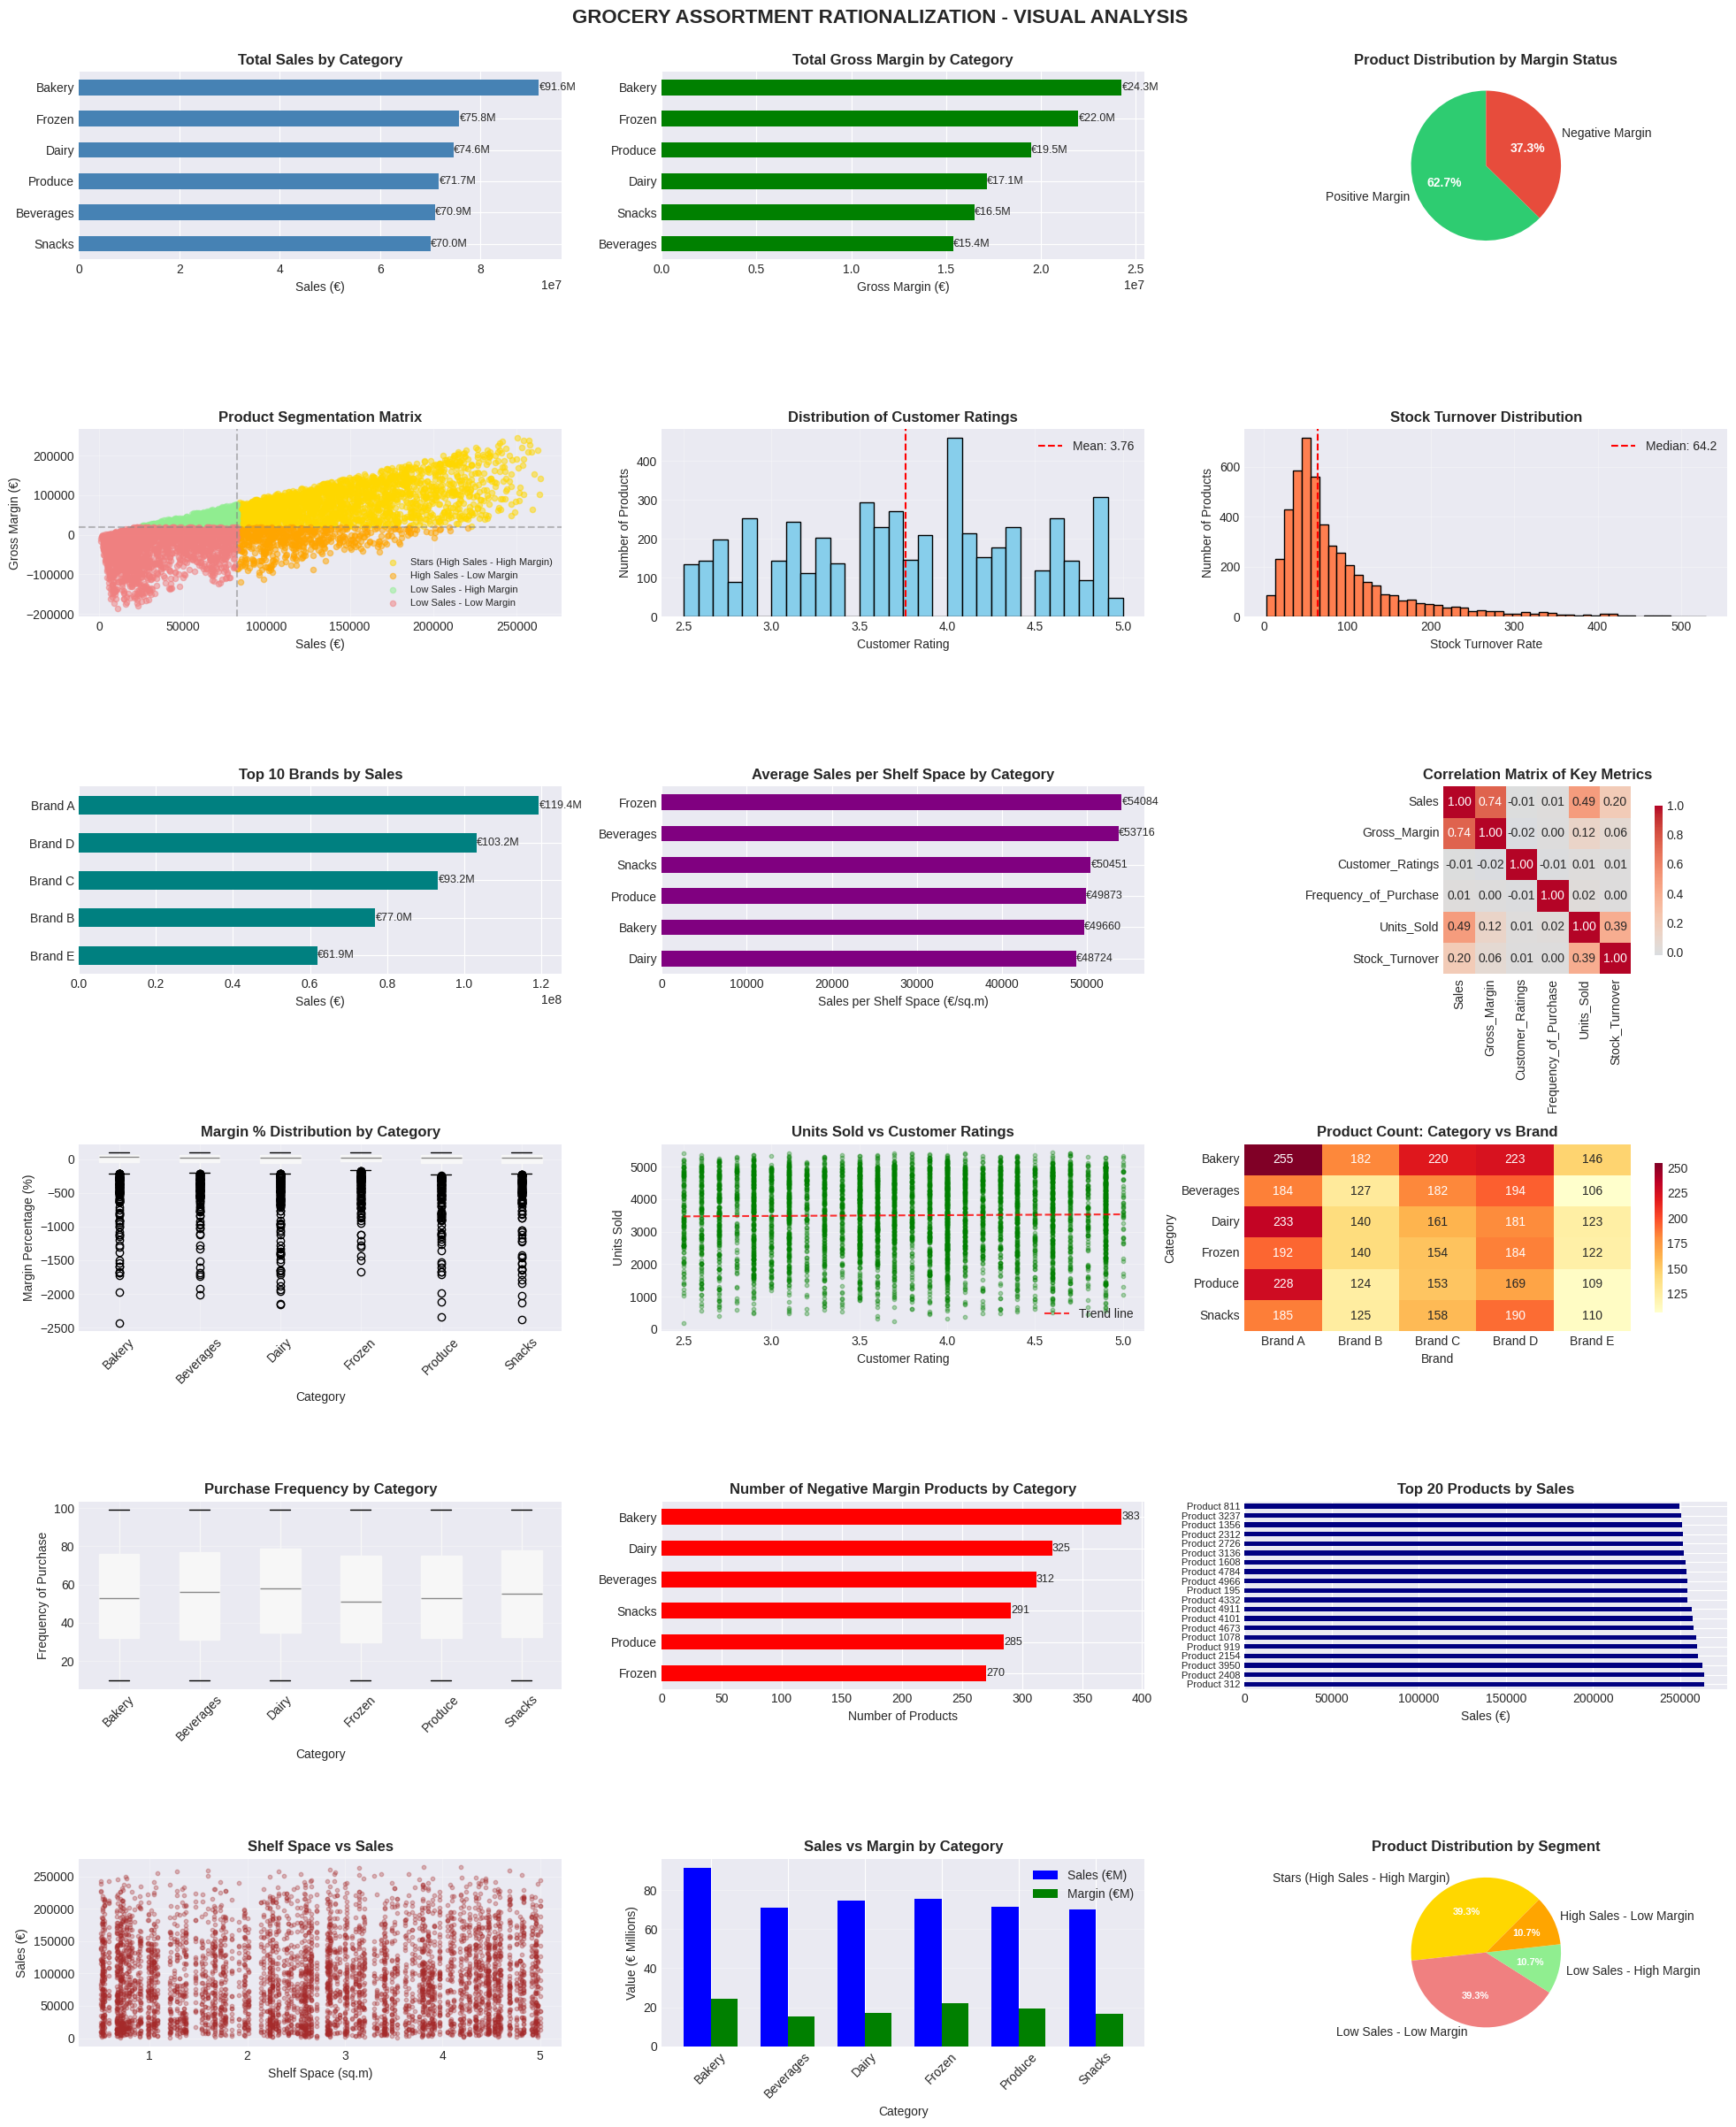

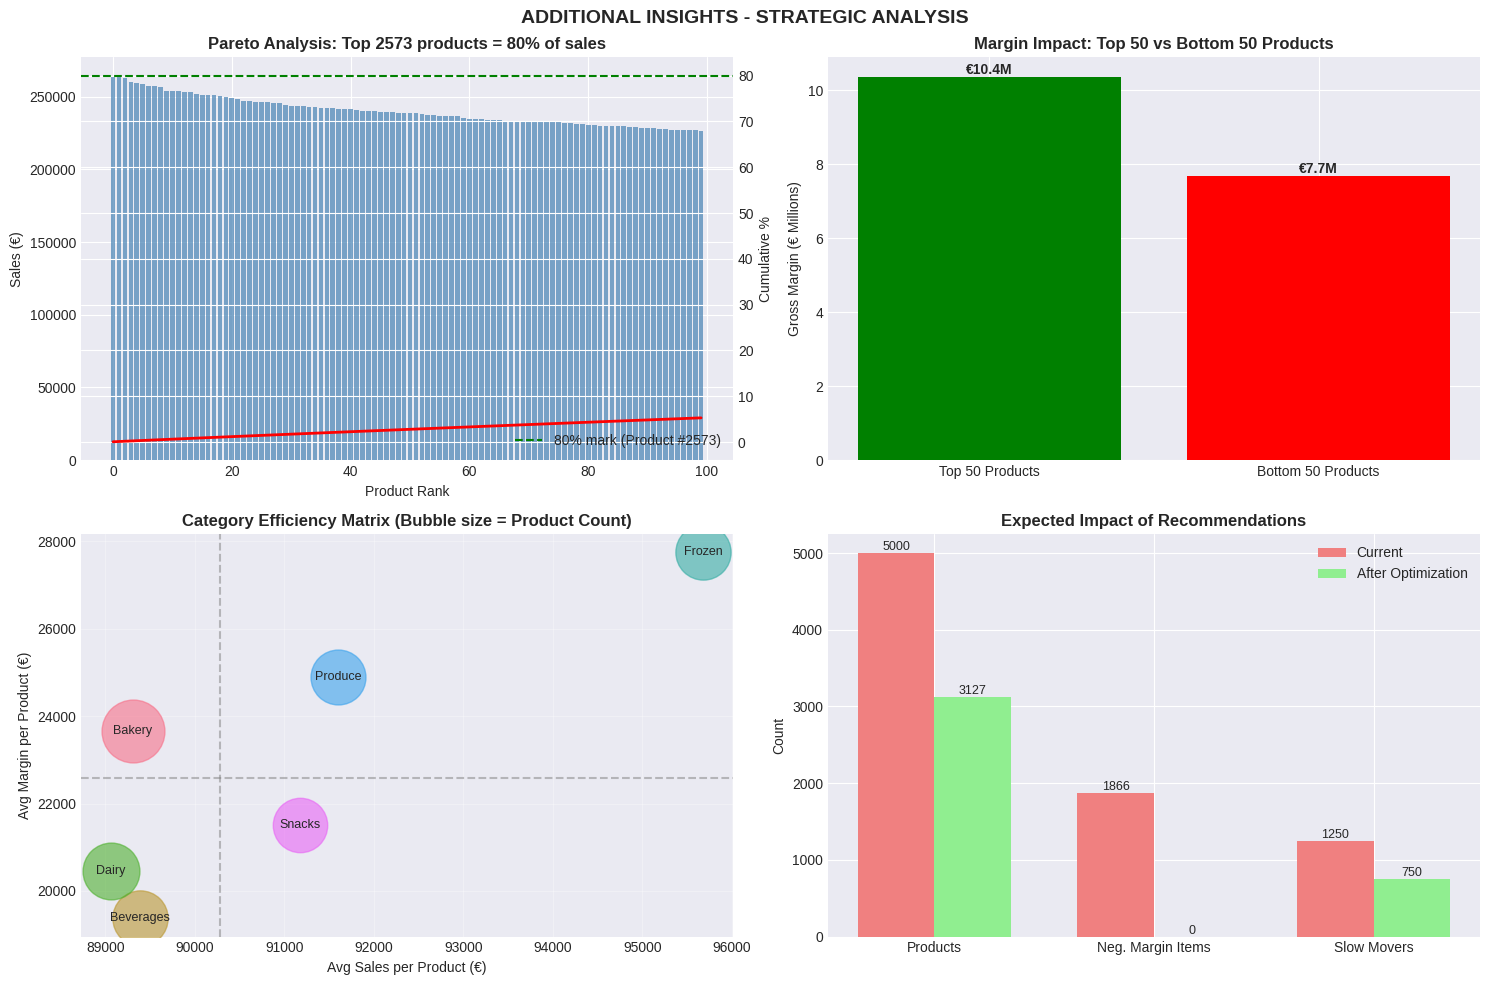

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set up visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the dataset
df = pd.read_csv('/content/Grocery_Dataset_python_mock_project.csv')

# Calculate additional metrics used in analysis
df['Stock_Turnover'] = df['Units_Sold'] / df['SKU']
df['Stock_Turnover'] = df['Stock_Turnover'].replace([np.inf, -np.inf], np.nan)
df['Sales_per_Shelf'] = df['Sales'] / df['Shelf_Space']
df['Sales_per_Shelf'] = df['Sales_per_Shelf'].replace([np.inf, -np.inf], np.nan)
df['Margin_per_Shelf'] = df['Gross_Margin'] / df['Shelf_Space']
df['Margin_per_Shelf'] = df['Margin_per_Shelf'].replace([np.inf, -np.inf], np.nan)
df['Margin_Percentage'] = (df['Gross_Margin'] / df['Sales'] * 100).replace([np.inf, -np.inf], np.nan)

# Define segments
sales_median = df['Sales'].median()
margin_median = df['Gross_Margin'].median()
df['Segment'] = 'Low Sales - Low Margin'
df.loc[(df['Sales'] >= sales_median) & (df['Gross_Margin'] >= margin_median), 'Segment'] = 'Stars (High Sales - High Margin)'
df.loc[(df['Sales'] >= sales_median) & (df['Gross_Margin'] < margin_median), 'Segment'] = 'High Sales - Low Margin'
df.loc[(df['Sales'] < sales_median) & (df['Gross_Margin'] >= margin_median), 'Segment'] = 'Low Sales - High Margin'


# Create a figure with multiple subplots
fig = plt.figure(figsize=(20, 24))

# 1. Sales and Margin by Category (Bar Charts)
ax1 = plt.subplot(6, 3, 1)
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=True)
category_sales.plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title('Total Sales by Category', fontsize=12, fontweight='bold')
ax1.set_xlabel('Sales (€)', fontsize=10)
ax1.set_ylabel('')
for i, v in enumerate(category_sales.values):
    ax1.text(v, i, f'€{v/1e6:.1f}M', va='center', fontsize=9)

ax2 = plt.subplot(6, 3, 2)
category_margin = df.groupby('Category')['Gross_Margin'].sum().sort_values(ascending=True)
colors = ['red' if x < 0 else 'green' for x in category_margin.values]
category_margin.plot(kind='barh', ax=ax2, color=colors)
ax2.set_title('Total Gross Margin by Category', fontsize=12, fontweight='bold')
ax2.set_xlabel('Gross Margin (€)', fontsize=10)
ax2.set_ylabel('')
for i, v in enumerate(category_margin.values):
    ax2.text(v, i, f'€{v/1e6:.1f}M', va='center', ha='right' if v < 0 else 'left', fontsize=9)

# 2. Product Distribution by Margin Status
ax3 = plt.subplot(6, 3, 3)
margin_status = pd.Series({
    'Positive Margin': len(df[df['Gross_Margin'] >= 0]),
    'Negative Margin': len(df[df['Gross_Margin'] < 0])
})
colors_pie = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = ax3.pie(margin_status.values, labels=margin_status.index,
                                     autopct='%1.1f%%', colors=colors_pie, startangle=90)
ax3.set_title('Product Distribution by Margin Status', fontsize=12, fontweight='bold')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# 3. Sales vs Gross Margin Scatter Plot (Segmentation)
ax4 = plt.subplot(6, 3, 4)
segment_colors = {'Stars (High Sales - High Margin)': 'gold',
                  'High Sales - Low Margin': 'orange',
                  'Low Sales - High Margin': 'lightgreen',
                  'Low Sales - Low Margin': 'lightcoral'}
for segment, color in segment_colors.items():
    segment_df = df[df['Segment'] == segment]
    ax4.scatter(segment_df['Sales'], segment_df['Gross_Margin'],
                alpha=0.5, s=20, label=segment, color=color)
ax4.axhline(y=margin_median, color='gray', linestyle='--', alpha=0.5)
ax4.axvline(x=sales_median, color='gray', linestyle='--', alpha=0.5)
ax4.set_xlabel('Sales (€)', fontsize=10)
ax4.set_ylabel('Gross Margin (€)', fontsize=10)
ax4.set_title('Product Segmentation Matrix', fontsize=12, fontweight='bold')
ax4.legend(fontsize=8, loc='best')
ax4.grid(True, alpha=0.3)

# 4. Customer Ratings Distribution
ax5 = plt.subplot(6, 3, 5)
df['Customer_Ratings'].hist(bins=30, ax=ax5, color='skyblue', edgecolor='black')
ax5.axvline(df['Customer_Ratings'].mean(), color='red', linestyle='--',
            label=f'Mean: {df["Customer_Ratings"].mean():.2f}')
ax5.set_xlabel('Customer Rating', fontsize=10)
ax5.set_ylabel('Number of Products', fontsize=10)
ax5.set_title('Distribution of Customer Ratings', fontsize=12, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 5. Stock Turnover Distribution
ax6 = plt.subplot(6, 3, 6)
df['Stock_Turnover'].dropna().hist(bins=50, ax=ax6, color='coral', edgecolor='black')
ax6.axvline(df['Stock_Turnover'].median(), color='red', linestyle='--',
            label=f'Median: {df["Stock_Turnover"].median():.1f}')
ax6.set_xlabel('Stock Turnover Rate', fontsize=10)
ax6.set_ylabel('Number of Products', fontsize=10)
ax6.set_title('Stock Turnover Distribution', fontsize=12, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)

# 6. Top 10 Brands by Sales
ax7 = plt.subplot(6, 3, 7)
top_brands = df.groupby('Brand')['Sales'].sum().nlargest(10).sort_values()
top_brands.plot(kind='barh', ax=ax7, color='teal')
ax7.set_title('Top 10 Brands by Sales', fontsize=12, fontweight='bold')
ax7.set_xlabel('Sales (€)', fontsize=10)
ax7.set_ylabel('')
for i, v in enumerate(top_brands.values):
    ax7.text(v, i, f'€{v/1e6:.1f}M', va='center', fontsize=9)

# 7. Sales per Shelf Space Efficiency
ax8 = plt.subplot(6, 3, 8)
category_shelf_efficiency = df.groupby('Category')['Sales_per_Shelf'].mean().sort_values()
category_shelf_efficiency.plot(kind='barh', ax=ax8, color='purple')
ax8.set_title('Average Sales per Shelf Space by Category', fontsize=12, fontweight='bold')
ax8.set_xlabel('Sales per Shelf Space (€/sq.m)', fontsize=10)
ax8.set_ylabel('')
for i, v in enumerate(category_shelf_efficiency.values):
    ax8.text(v, i, f'€{v:.0f}', va='center', fontsize=9)

# 8. Correlation Heatmap
ax9 = plt.subplot(6, 3, 9)
corr_matrix = df[['Sales', 'Gross_Margin', 'Customer_Ratings', 'Frequency_of_Purchase',
                   'Units_Sold', 'Stock_Turnover']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=ax9, cbar_kws={"shrink": 0.8})
ax9.set_title('Correlation Matrix of Key Metrics', fontsize=12, fontweight='bold')

# 9. Margin Percentage by Category (Box Plot)
ax10 = plt.subplot(6, 3, 10)
df.boxplot(column='Margin_Percentage', by='Category', ax=ax10, patch_artist=True)
ax10.set_xlabel('Category', fontsize=10)
ax10.set_ylabel('Margin Percentage (%)', fontsize=10)
ax10.set_title('Margin % Distribution by Category', fontsize=12, fontweight='bold')
plt.sca(ax10)
plt.xticks(rotation=45)
ax10.grid(True, alpha=0.3)

# 10. Units Sold vs Customer Ratings
ax11 = plt.subplot(6, 3, 11)
ax11.scatter(df['Customer_Ratings'], df['Units_Sold'], alpha=0.3, s=10, color='green')
z = np.polyfit(df['Customer_Ratings'], df['Units_Sold'], 1)
p = np.poly1d(z)
ax11.plot(df['Customer_Ratings'].sort_values().unique(),
          p(df['Customer_Ratings'].sort_values().unique()),
          "r--", alpha=0.8, label='Trend line')
ax11.set_xlabel('Customer Rating', fontsize=10)
ax11.set_ylabel('Units Sold', fontsize=10)
ax11.set_title('Units Sold vs Customer Ratings', fontsize=12, fontweight='bold')
ax11.legend()
ax11.grid(True, alpha=0.3)

# 11. Product Count by Category and Brand
ax12 = plt.subplot(6, 3, 12)
pivot_table = df.pivot_table(index='Category', columns='Brand', values='Product_ID', aggfunc='count')
sns.heatmap(pivot_table, annot=True, fmt='g', cmap='YlOrRd', ax=ax12, cbar_kws={"shrink": 0.8})
ax12.set_title('Product Count: Category vs Brand', fontsize=12, fontweight='bold')
ax12.set_xlabel('Brand', fontsize=10)
ax12.set_ylabel('Category', fontsize=10)

# 12. Frequency of Purchase Distribution by Category
ax13 = plt.subplot(6, 3, 13)
df.boxplot(column='Frequency_of_Purchase', by='Category', ax=ax13, patch_artist=True)
ax13.set_xlabel('Category', fontsize=10)
ax13.set_ylabel('Frequency of Purchase', fontsize=10)
ax13.set_title('Purchase Frequency by Category', fontsize=12, fontweight='bold')
plt.sca(ax13)
plt.xticks(rotation=45)
ax13.grid(True, alpha=0.3)

# 13. Negative Margin Products by Category
ax14 = plt.subplot(6, 3, 14)
negative_by_cat = df[df['Gross_Margin'] < 0].groupby('Category').size().sort_values()
negative_by_cat.plot(kind='barh', ax=ax14, color='red')
ax14.set_title('Number of Negative Margin Products by Category', fontsize=12, fontweight='bold')
ax14.set_xlabel('Number of Products', fontsize=10)
ax14.set_ylabel('')
for i, v in enumerate(negative_by_cat.values):
    ax14.text(v, i, str(v), va='center', fontsize=9)

# 14. Top Products by Sales (Top 20)
ax15 = plt.subplot(6, 3, 15)
top_products = df.nlargest(20, 'Sales')[['Product_Name', 'Sales']].set_index('Product_Name')['Sales']
top_products.plot(kind='barh', ax=ax15, color='navy')
ax15.set_title('Top 20 Products by Sales', fontsize=12, fontweight='bold')
ax15.set_xlabel('Sales (€)', fontsize=10)
ax15.set_ylabel('')
ax15.tick_params(axis='y', labelsize=8)

# 15. Shelf Space vs Sales Efficiency
ax16 = plt.subplot(6, 3, 16)
ax16.scatter(df['Shelf_Space'], df['Sales'], alpha=0.3, s=10, color='brown')
ax16.set_xlabel('Shelf Space (sq.m)', fontsize=10)
ax16.set_ylabel('Sales (€)', fontsize=10)
ax16.set_title('Shelf Space vs Sales', fontsize=12, fontweight='bold')
ax16.grid(True, alpha=0.3)

# 16. Category Performance Summary
ax17 = plt.subplot(6, 3, 17)
category_performance = df.groupby('Category').agg({
    'Sales': 'sum',
    'Gross_Margin': 'sum'
}).reset_index()
x = np.arange(len(category_performance))
width = 0.35
bars1 = ax17.bar(x - width/2, category_performance['Sales']/1e6, width, label='Sales (€M)', color='blue')
bars2 = ax17.bar(x + width/2, category_performance['Gross_Margin']/1e6, width, label='Margin (€M)', color='green')
ax17.set_xlabel('Category', fontsize=10)
ax17.set_ylabel('Value (€ Millions)', fontsize=10)
ax17.set_title('Sales vs Margin by Category', fontsize=12, fontweight='bold')
ax17.set_xticks(x)
ax17.set_xticklabels(category_performance['Category'], rotation=45)
ax17.legend()
ax17.grid(True, alpha=0.3, axis='y')

# 18. Product Segmentation Pie Chart
ax18 = plt.subplot(6, 3, 18)
segment_counts = df['Segment'].value_counts()
colors_seg = ['gold', 'lightcoral', 'lightgreen', 'orange']
wedges, texts, autotexts = ax18.pie(segment_counts.values, labels=segment_counts.index,
                                      autopct='%1.1f%%', colors=colors_seg, startangle=45)
ax18.set_title('Product Distribution by Segment', fontsize=12, fontweight='bold')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(8)

# Adjust layout
plt.suptitle('GROCERY ASSORTMENT RATIONALIZATION - VISUAL ANALYSIS',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()

# Save the figure
plt.savefig('grocery_analysis_visualizations.png', dpi=150, bbox_inches='tight')

# Create a second figure for additional insights
fig2, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Pareto Chart for Sales
ax = axes[0, 0]
products_sorted = df.sort_values('Sales', ascending=False).reset_index(drop=True)
products_sorted['Cumulative_Sales'] = products_sorted['Sales'].cumsum()
products_sorted['Cumulative_Percentage'] = (products_sorted['Cumulative_Sales'] / products_sorted['Sales'].sum()) * 100

# Find 80% mark
idx_80 = (products_sorted['Cumulative_Percentage'] <= 80).sum()

ax.bar(range(len(products_sorted[:100])), products_sorted['Sales'][:100].values, color='steelblue', alpha=0.7)
ax2 = ax.twinx()
ax2.plot(range(len(products_sorted[:100])), products_sorted['Cumulative_Percentage'][:100].values,
         color='red', marker='', linewidth=2)
ax2.axhline(y=80, color='green', linestyle='--', label=f'80% mark (Product #{idx_80})')
ax.set_xlabel('Product Rank', fontsize=10)
ax.set_ylabel('Sales (€)', fontsize=10)
ax2.set_ylabel('Cumulative %', fontsize=10)
ax.set_title(f'Pareto Analysis: Top {idx_80} products = 80% of sales', fontsize=12, fontweight='bold')
ax2.legend()

# 2. Margin Analysis - Winners vs Losers
ax = axes[0, 1]
top_margin = df.nlargest(50, 'Gross_Margin')['Gross_Margin'].sum()
bottom_margin = df.nsmallest(50, 'Gross_Margin')['Gross_Margin'].sum()
data = {'Top 50 Products': top_margin/1e6, 'Bottom 50 Products': abs(bottom_margin)/1e6}
bars = ax.bar(data.keys(), data.values(), color=['green', 'red'])
ax.set_ylabel('Gross Margin (€ Millions)', fontsize=10)
ax.set_title('Margin Impact: Top 50 vs Bottom 50 Products', fontsize=12, fontweight='bold')
for bar, value in zip(bars, data.values()):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'€{value:.1f}M', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 3. Category Efficiency Matrix
ax = axes[1, 0]
category_metrics = df.groupby('Category').agg({
    'Sales': 'sum',
    'Gross_Margin': 'sum',
    'Product_ID': 'count'
}).reset_index()
category_metrics['Sales_per_Product'] = category_metrics['Sales'] / category_metrics['Product_ID']
category_metrics['Margin_per_Product'] = category_metrics['Gross_Margin'] / category_metrics['Product_ID']

for i, row in category_metrics.iterrows():
    ax.scatter(row['Sales_per_Product'], row['Margin_per_Product'],
               s=row['Product_ID']*2, alpha=0.6)
    ax.annotate(row['Category'], (row['Sales_per_Product'], row['Margin_per_Product']),
                ha='center', va='center', fontsize=9)

ax.axhline(y=category_metrics['Margin_per_Product'].median(), color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=category_metrics['Sales_per_Product'].median(), color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Avg Sales per Product (€)', fontsize=10)
ax.set_ylabel('Avg Margin per Product (€)', fontsize=10)
ax.set_title('Category Efficiency Matrix (Bubble size = Product Count)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# 4. Recommendation Impact
ax = axes[1, 1]
current_metrics = {
    'Products': len(df),
    'Neg. Margin Items': len(df[df['Gross_Margin'] < 0]),
    'Slow Movers': len(df[df['Stock_Turnover'] < df['Stock_Turnover'].quantile(0.25)])
}
after_metrics = {
    'Products': len(df) - 1873,  # After elimination
    'Neg. Margin Items': 0,
    'Slow Movers': len(df[df['Stock_Turnover'] < df['Stock_Turnover'].quantile(0.25)]) - 500  # Estimated
}

x = np.arange(len(current_metrics))
width = 0.35
bars1 = ax.bar(x - width/2, list(current_metrics.values()), width, label='Current', color='lightcoral')
bars2 = ax.bar(x + width/2, list(after_metrics.values()), width, label='After Optimization', color='lightgreen')

ax.set_ylabel('Count', fontsize=10)
ax.set_title('Expected Impact of Recommendations', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(list(current_metrics.keys()))
ax.legend()

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=9)

plt.suptitle('ADDITIONAL INSIGHTS - STRATEGIC ANALYSIS', fontsize=14, fontweight='bold')
plt.tight_layout()

# Save the second figure
plt.savefig('grocery_strategic_insights.png', dpi=150, bbox_inches='tight')


